In [1]:
import torch
import math
import einops

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

from pathlib import Path
from dataclasses import replace, dataclass, field




In [2]:
### SHORTCUTS
from torch.special import ndtr as phi
from torch.special import ndtri as phi_inv

### HELPER FUNCTIONS
def exists(val):
    return val is not None

def default(val, d):
    return val if exists(val) else d

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [3]:
@dataclass(kw_only=True)
class ObjectiveConfig:
    epsilon: float = 1e-4
    

In [4]:
@dataclass(kw_only=True)
class WorldConfig:
    lattice_sizes: dict
    patch_sizes: dict = field(default_factory= dict)
    
    # derived fields:
    coarse_sizes: dict = field(init=False)

    lattice_pattern: str = field(init=False)
    coarse_pattern: str = field(init=False)
    patch_pattern: str = field(init=False)

    coarse_numel: int = field(init=False)
    lattice_numel: int = field(init=False)
    patch_numel: int = field(init=False)

    coarse_shape: tuple = field(init=False)
    lattice_shape: tuple = field(init=False)
    patch_shape: tuple = field(init=False)

    coarse_layout: tuple = field(init=False)
    lattice_layout: tuple = field(init=False)
    patch_layout: tuple = field(init=False)

    def __post_init__(self):
        self.lattice_layout = tuple(self.lattice_sizes.keys())
        self.coarse_layout = tuple(self.lattice_sizes.keys())
        self.patch_layout = tuple(f"{k*2}" for k in self.lattice_layout)

        self.patch_sizes = {key: self.patch_sizes.get(key, 1) for key in self.patch_layout}
        self.coarse_sizes = {}
        for ax in self.lattice_layout:
            assert self.lattice_sizes[ax] % self.patch_sizes[ax * 2] == 0, f'{ax} not divisible by {self.patch_sizes[ax * 2]}' 
            self.coarse_sizes[ax] = (self.lattice_sizes[ax] // self.patch_sizes[f'{ax*2}'])

        self.lattice_pattern = " ".join(f"({f} {p})" for f, p in zip(self.lattice_layout, self.patch_layout))
        self.patch_pattern = ' '.join(self.patch_layout)
        self.coarse_pattern = ' '.join(self.coarse_layout)     

        self.coarse_numel = math.prod(self.coarse_sizes.values()) 
        self.lattice_numel = math.prod(self.lattice_sizes.values()) 
        self.patch_numel = math.prod(self.patch_sizes.values())

        self.coarse_shape = tuple(self.coarse_sizes[ax] for ax in self.coarse_layout)
        self.lattice_shape = tuple(self.lattice_sizes[ax] for ax in self.lattice_layout)
        self.patch_shape = tuple(self.patch_sizes[ax] for ax in self.patch_layout)

In [5]:
class EinTask(torch.nn.Module):
    def __init__(self, world: WorldConfig, objective: ObjectiveConfig):
        super().__init__()
        self.register_buffer('epsilon', torch.tensor(objective.epsilon))
        self.generator = torch.Generator(device = self.device, seed = objective.seed)

        self.objective = objective
        self.world = world

    @property
    def device(self) -> torch.device: return self.epsilon.device

    @staticmethod
    def binary_topk(reservoir: torch.FloatTensor, rate: torch.LongTensor, event_dim: int = -1) -> torch.BoolTensor:
        return rate > reservoir.argsort(descending=True, dim = event_dim).argsort(dim = event_dim)

    def sample_coupled_uniform(self, B: int, K: int, coupling: float = 0):
        Z = torch.randn((2, B, K), device=self.device, generator=self.generator)
        Z[1] = coupling * Z[0] + Z[1] * (1 - coupling**2)**0.5
        return phi(Z)

In [6]:
def coupled_uniform(B, K, coupling = 0):
    Z = torch.randn((2, B, K))
    Z[1] = coupling * Z[0] + Z[1] * (1 - coupling**2)**0.5
    return phi(Z)

In [164]:
def sample_kendall_mallows(B, K, theta):
    u = torch.rand(B, K)
    q = torch.expm1(-theta * torch.arange(K, 0, -1)) # geometric weights: e**(-theta * idcs) - 1
    V = torch.log1p(u * q).div(-theta) # inverse cdf: -1/theta * log(1 + u * q) 
    W = V.ceil().long() # -> [1, K]

    avail = torch.ones((B, K), dtype=torch.long)
    pi = torch.empty_like(avail)

    for k in range(K):
        idx = torch.searchsorted(avail.cumsum(-1), W[..., k:k+1])
        pi[..., k] = idx[..., 0]
        avail.scatter_(-1, idx, 0)

    return pi

def coupled_uniform(B, K, coupling = 0):
    Z = torch.randn((2, B, K))
    Z[1] = coupling * Z[0] + Z[1] * (1 - coupling**2)**0.5
    return phi(Z)

In [165]:
rate = 64
# concentration
Uk = coupled_uniform(B, K, coupling).div(alpha)

# permutation
rank = Uk[0].argsort(descending=True)
permutation = sample_kendall_mallows(B, K, theta)
Uk = Uk.gather(-1, rank[None])
Uk = Uk.gather(-1, permutation[None])

# per-token reservoir
U = coupled_uniform(B, N, 0) + einops.repeat(Uk, "... k -> ... (k kk)", kk = N // K)

# topk selection
binary = rate > U.argsort(descending= True).argsort()

In [166]:
binary.shape

torch.Size([2, 1024, 256])

In [167]:
def expected_kendall_distance(theta, K):
    theta = torch.as_tensor(theta)

    j = torch.arange(
        1, K + 1,
        device=theta.device,
        dtype=theta.dtype,
    )

    # E[C_j] = 1/expm1(theta) - j/expm1(j*theta)
    t = theta[..., None]
    jt = j * t

    # theta -> 0 has a removable singularity
    e = 1.0 / torch.expm1(t) - j / torch.expm1(jt)

    # Explicit limiting value at theta = 0:
    # E[C_j] -> (j - 1) / 2
    limit = (j - 1) / 2

    e = torch.where(
        torch.abs(t) < 1e-6,
        limit,
        e,
    )

    return e.sum(dim=-1)

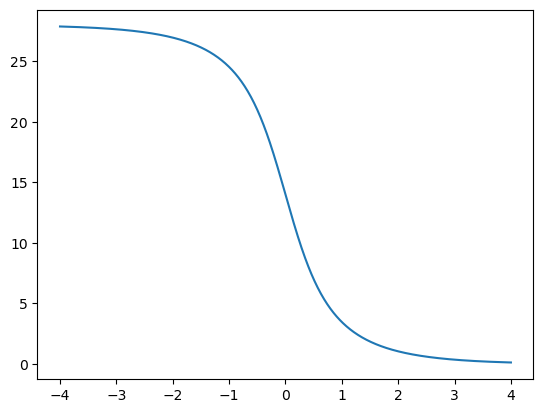

In [187]:
thetas = torch.linspace(-4, 4, 1000)
plt.plot(thetas, expected_kendall_distance(theta = thetas, K = 8))

In [211]:
K = 8
B = 1024
N = 256
R = 64

thetas = torch.cat([-torch.logspace(2, -4, 11, base = 2), torch.logspace(-4, 2, 11, base = 2)])
alphas = torch.logspace(-4, 3, 21, base = 2)
couplings = torch.linspace(-1, 1, 5)

profiles = torch.zeros((len(alphas), len(thetas), len(couplings), 2, K))
for i, alpha in enumerate(alphas):
    for j,theta in enumerate(thetas):
        for c, coupling in enumerate(couplings):
            U_a, U_b = coupled_uniform(B, K, coupling), coupled_uniform(B, N, 0)
            Uk = U_a.log().div(alpha)
            
            rank = U_a[0].argsort(descending=True)
            rank = einops.repeat(rank, '... -> two ...', two = 2)
            Uk = Uk.gather(-1, rank)

            km = sample_kendall_mallows(B, K, -theta)
            PIk = einops.repeat(km, "... -> two ...", two = 2)
            Uk = Uk.gather(-1, PIk)

            U = U_b.log() + einops.repeat(Uk, "... k -> ... (k kk)", kk = N // K)

            binary = R > U.argsort(descending= True).argsort()
            profiles[i, j, c] = einops.reduce(binary.float(), 'two b (k kk) -> two k', k = K, reduction="mean")

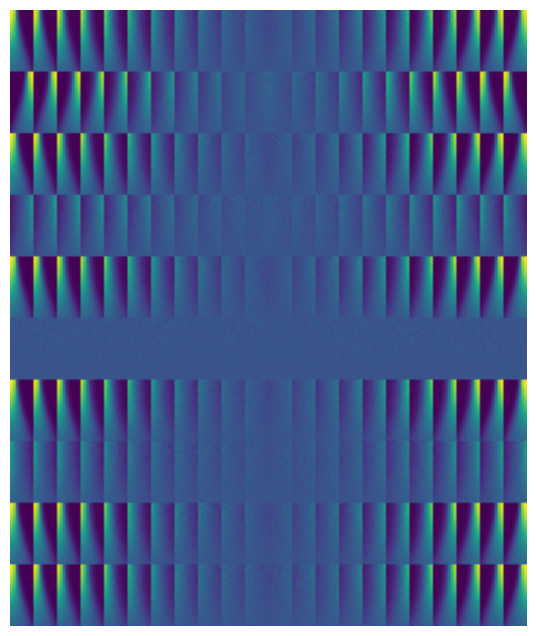

In [213]:
plt.figure(figsize=(12, 8))
plt.imshow(einops.rearrange(profiles, 'a t c r f -> (c r a) (t f)'))
plt.axis('off')
plt.show()

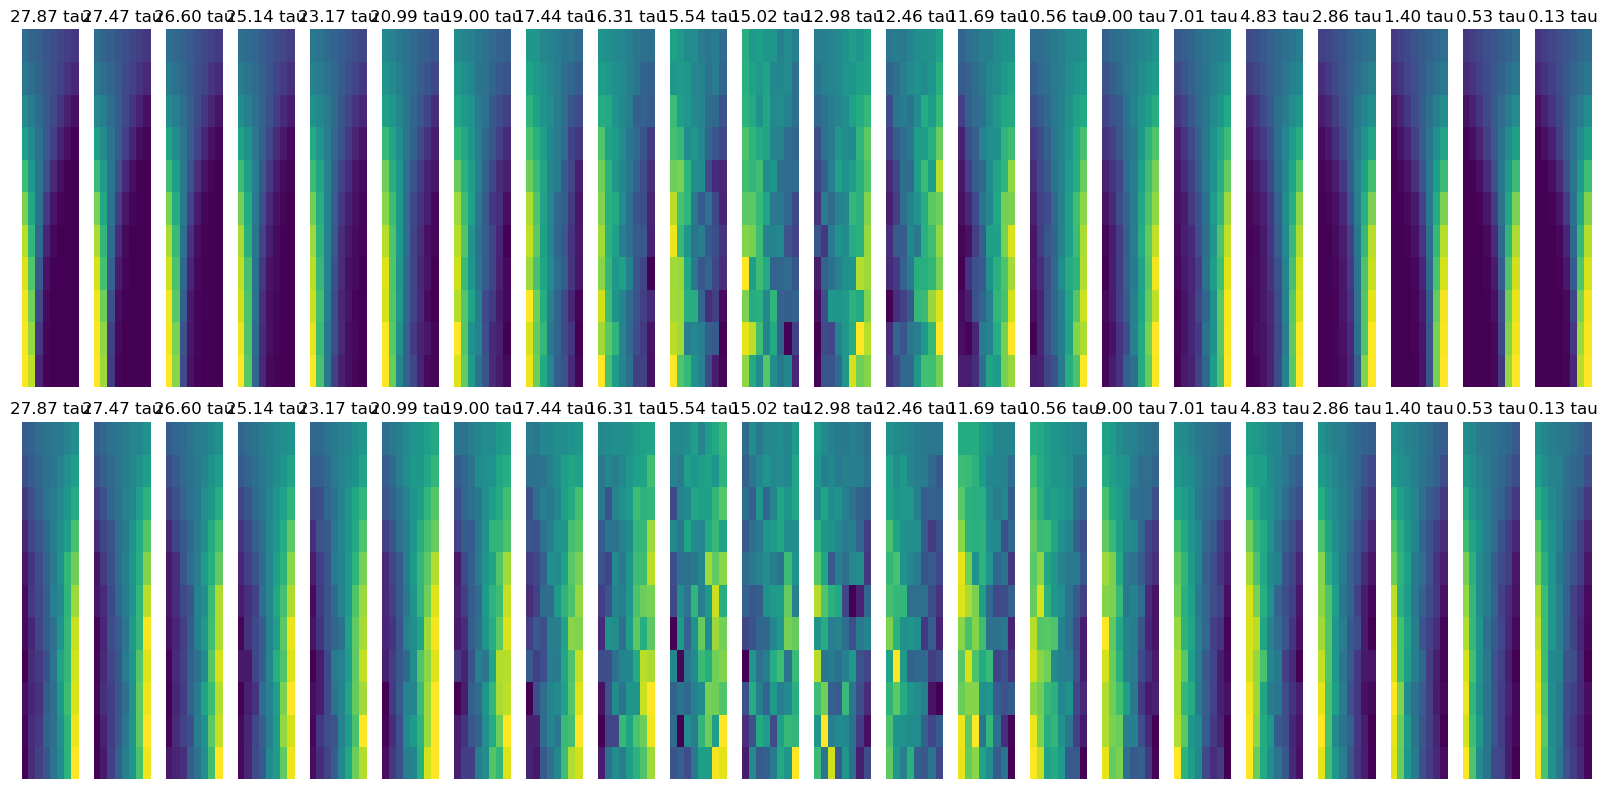

In [193]:
fig, axs = plt.subplots(2, len(thetas), figsize = (16, 8))
for i,k in enumerate(thetas):
    for j in range(2):
        plt.sca(axs[j,i])
        plt.pcolor(profiles[:,i,j])
        plt.title(f'{expected_kendall_distance(k, K):.2f} tau')
        plt.axis("off")
plt.tight_layout()

Text(0.5, 1.0, 'alpha = 0.76')

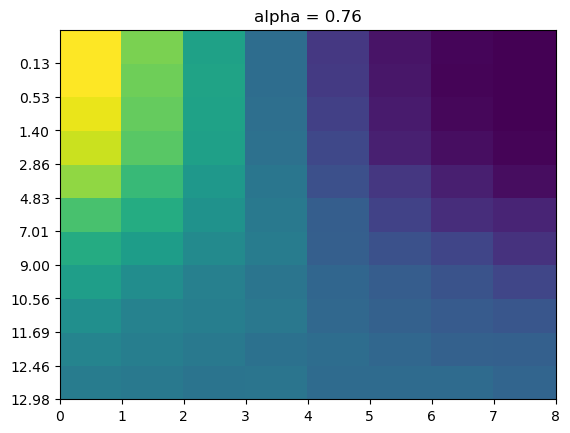

In [179]:
a = 6
plt.pcolor(profiles[a, :, 0])
plt.yticks(np.arange(len(thetas)), [f'{expected_kendall_distance(theta, K).item():.2f}' for theta in thetas])
plt.title(f"alpha = {alphas[a]:.2f}")

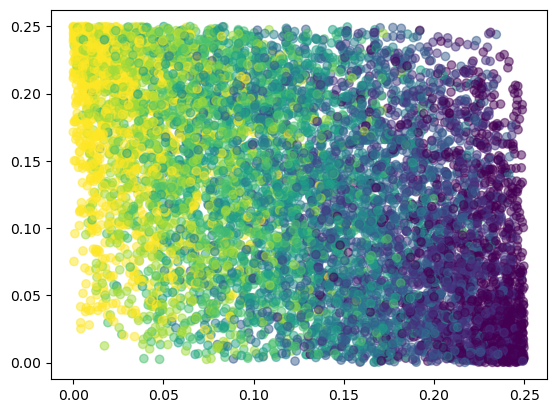

In [181]:
plt.scatter(Uk[0], Uk[1], c=einops.repeat(np.arange(K), "k -> b k", b = B), cmap="viridis", alpha = 0.5)

In [568]:
# trunc normal
coupling = -0.9
mu, sigma = 0.2, 0.2
lower, upper = 0.2, 0.8

U = coupled_uniform(B, K, coupling)
a = phi(torch.tensor((lower - mu) / sigma))
b = phi(torch.tensor((upper - mu) / sigma))

Z = phi_inv(U * (b - a) + a) * sigma + mu 

(-0.1, 1.1)

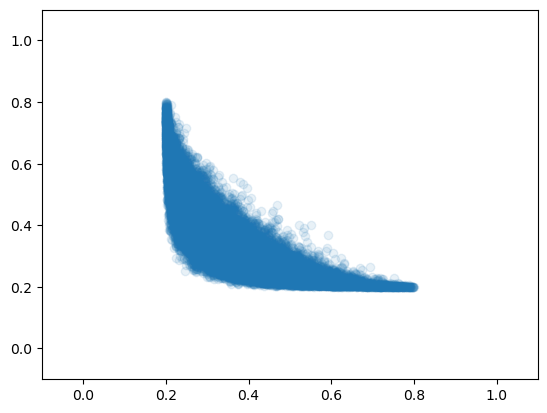

In [569]:
plt.scatter(Z[0].flatten(), Z[1].flatten(), alpha= 0.1)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

In [570]:
theta = 0.1
K = 16

u = torch.rand((B, K))

In [588]:
center = None
n = torch.arange(K - 1, 0, -1)
q_ref = math.exp(-theta)
V_ref = (-torch.log1p(-u[:, :-1] * (1 - q_ref ** (n + 1))) / theta).floor().long()
V_ref = torch.cat([V_ref, V_ref.new_zeros((B, 1))], dim = -1)

avail_ref = torch.ones((B, K), dtype=torch.long)
pi_ref = torch.empty_like(avail_ref)
for k in range(K):
    pi_ref[:, k] = torch.searchsorted(avail_ref.cumsum(-1), V_ref[:, k:k+1] + 1).squeeze(-1)
    avail_ref.scatter_(-1, pi_ref[:, k:k+1], 0)

if exists(center):
    pi_ref = pi_ref.gather(-1, center.argsort()[None].expand(B, -1))

In [635]:
q = torch.arange(K, 0, -1).mul(-theta).exp() # geometric weights: e**(-theta * idcs)
V = torch.log1p(-u * (1 - q)).div(-theta) # inverse cdf: -1/theta * log(1 - u * (1 - q)) 
W = V.ceil().long() # -> [1, K]

avail = torch.ones((B, K), dtype=torch.long)
pi = torch.empty_like(avail)

for k in range(K):
    idx = torch.searchsorted(avail.cumsum(-1), W[..., k:k+1])
    pi[..., k] = idx[..., 0]
    avail.scatter_(-1, idx, 0)


In [609]:
pi.allclose(pi_ref)

True

In [636]:
pi

tensor([[ 1,  0,  2,  ..., 13, 14, 15],
        [ 0,  3,  1,  ..., 13, 15, 14],
        [ 0,  1,  3,  ..., 12, 14, 15],
        ...,
        [ 0,  1,  3,  ..., 13, 15, 14],
        [ 0,  1,  2,  ..., 13, 14, 15],
        [ 0,  1,  2,  ..., 13, 14, 15]])

In [6]:
lattice = WorldConfig(
    lattice_sizes={"v": 4, "t": 12, "h": 16, "w": 30}, patch_sizes={'tt': 3}
)

In [ ]:
class EinTask(torch.nn.Module):
    def __init__(self, world: WorldConfig, objective: ObjectiveConfig):
        super().__init__()
        self.register_buffer('epsilon', torch.tensor(objective.epsilon))
        self.generator = torch.Generator(device = self.device, seed = objective.seed)

        self.objective = objective
        self.world = world

    @property
    def device(self) -> torch.device: return self.epsilon.device

    @staticmethod
    def binary_topk_(P: torch.FloatTensor, R: torch.LongTensor, dim: int = -1) -> torch.BoolTensor:
        return R > P.argsort(descending=True, dim = dim).argsort(dim = dim)

    def rate_to_num(self, rate: float):
        return torch.tensor(rate * self.world.num_tokens, dtype= torch.long, device = self.device)
        
    def sample_block_size(self, K: int):
        block_weight = self.objective.kwargs.get('block_weight', None)
        KK = 1
        if exists(block_weight):
            d = torch.arange(1, K + 1, device=self.device)
            d = d[K % d == 0]
            KK = d[torch.multinomial(1 / d.pow(block_weight), 1, generator=self.generator)]
        return KK

    def sample_coupled_noise(self, B: int, K: int, coupling: float):
        Z = torch.randn((2, B, K), device=self.device, generator=self.generator)
        Z[1] = coupling * Z[0] + Z[1] * (1 - coupling**2)**0.5
        return Z

    def sample_antithetic_weighted_reservoir(self, B: int):
        P = torch.rand((2, B, self.world.num_tokens), device=self.device, generator=self.generator).log()
        for dim, cfg in self.objective.event_cfg.items():
            if not (exists(cfg) and dim in self.world.layout): continue

            alpha, coupling, theta = cfg.get("alpha"), cfg.get('coupling', 0), cfg.get('theta', 0)

            K = self.world.token_sizes[dim]
            KK = self.sample_block_size(K)
            pi = self.sample_orientation(B, K // KK, theta)
            Z = self.sample_coupled_noise(B, K // KK, coupling)
            Z = Z.gather(-1, pi)
            Z = einops.repeat(Z, '2 b k -> 2 b (k kk)', kk=KK)
            U = torch.special.ndtr(Z)
            U = einops.repeat(U, f'2 b {dim} -> 2 b ({self.world.token_pattern})', **self.world.token_sizes)
            P += U.log().div(alpha)

        return P
    
        
        

        


In [175]:
einops.repeat(torch.ones((5,)), 't -> (t tt)', tt = torch.tensor(5))

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1.])

In [178]:
B = 1000
K = 12
theta = 1

n = torch.arange(K - 1, 0, -1)
u = torch.rand((B, K - 1))


In [ ]:
class TruncNormalPPF(torch.nn.Module):
    def __init__(self, mu: float, sigma: float, lower_bound: float = 0., upper_bound: float = 1., eps: float = 1e-2) -> None:
        super().__init__()

        self.register_buffer('mu', torch.tensor(mu))
        self.register_buffer('sigma', torch.tensor(sigma))
        self.register_buffer('eps', torch.tensor(eps))
        self.register_buffer('lower_bound', torch.tensor(max(eps, lower_bound)))
        self.register_buffer('upper_bound', torch.tensor(min(1 - eps, upper_bound)))

        assert 0. < self.sigma, 'sigma must be positive'
        assert self.lower_bound < self.upper_bound, 'lower bound has to be smaller than upper bound'

    @classmethod
    def mirror(cls, other):
        return cls(
            mu = 1 - other.mu.item(), 
            sigma = other.sigma.item(),
            lower_bound = 1 - other.upper_bound.item(), 
            upper_bound = 1 - other.lower_bound.item(),
            eps = other.eps.item())

    @property
    def device(self) -> torch.device: return self.mu.device

    def forward(self, U: torch.FloatTensor):
        a = phi((self.lower_bound - self.mu) / self.sigma)
        b = phi((self.upper_bound - self.mu) / self.sigma)
        return self.mu + self.sigma * phi_inv(a + (b - a) * U)

In [172]:
ppf_src = TruncNormalPPF(0.2, 1e-6, 0.01, 0.3)
ppf_tgt = TruncNormalPPF(0.8, 1e-6, 0.7, 0.99)

In [164]:
B = 10000
rho = 0
z_src, z = torch.randn((2, B))
z_tgt = rho * z_src + z * (1 - rho**2)**0.5

In [165]:
rho_src, rho_tgt = ppf_src(z_src), ppf_tgt(z_tgt)

In [166]:
cat = torch.stack([rho_src, rho_tgt])

In [167]:
cat.sum(0)

tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000])

In [168]:
torch.corrcoef(cat)

tensor([[1.0000, 0.0038],
        [0.0038, 1.0000]])